# 전체 학습 과정 및 아키텍쳐

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Phase 1~2는 인덱싱 단계입니다. 데이터를 청킹해서 LLM이 그래프로 만들고 Neo4j에 저장합니다. 이어서 검색·생성 단계입니다.

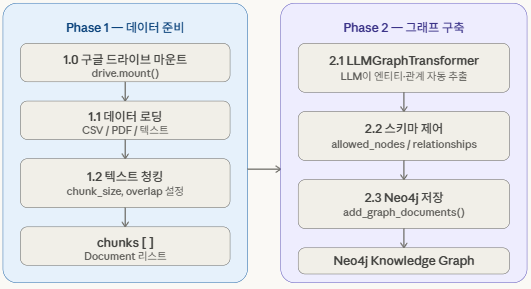

Phase 3~4는 검색·생성 단계입니다. 질문이 들어오면 그래프 탐색과 벡터 검색을 동시에 하고 합쳐서 LLM에게 넘깁니다. 마지막으로 Phase 5입니다.  
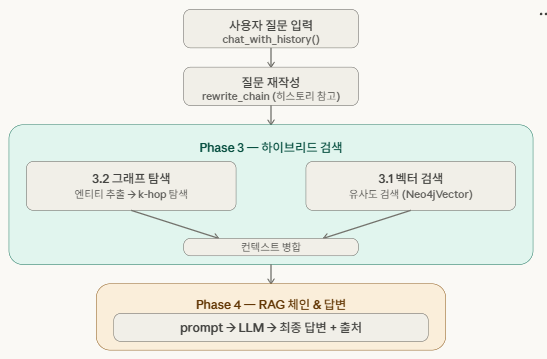

Phase 5는 Phase 3~4의 하이브리드 검색과 달리 질문 유형에 따라 한 경로만 실행합니다. 관계형 질문이면 그래프만, 의미 검색이면 벡터만 타서 불필요한 API 호출을 줄입니다.  
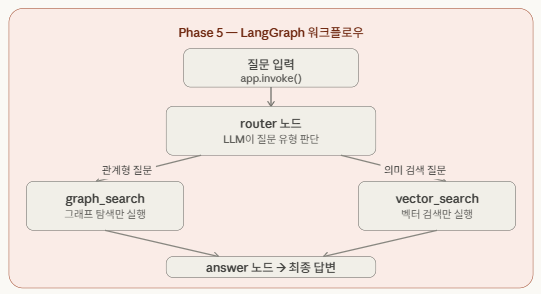

# Phase 0 — 개념 이해 & 환경 준비

## 0.1 GraphRAG vs 일반 RAG — 언제 써야 하나?
- **일반 RAG**는 문서를 청크로 쪼개고 벡터 유사도로 검색합니다. "이 문장과 비슷한 청크를 찾아줘" 방식이라, 단순 사실 조회에는 충분합니다.

- **GraphRAG**는 여기에 더해 엔티티(노드)와 관계(엣지)로 이뤄진 지식 그래프를 활용합니다. "A는 B와 어떤 관계인가?", "C를 통해 연결된 모든 D를 찾아줘" 같은 다중 홉 추론이 필요할 때 강점을 발휘합니다.

- **GraphRAG를 선택해야 할 때**:
· 엔티티 간 관계가 중요한 데이터 (논문, 계약서, 조직도, 제품 카탈로그)
· 여러 문서를 가로질러 추론해야 하는 질문
· "누가 누구와 일했나", "어떤 제품이 어떤 카테고리에 속하나" 같은 관계형 질문

## 0.2 최신 GraphRAG 전체

- Indexing (그래프 구축)  
문서 로드 → 청킹 → LLMGraphTransformer로 엔티티·관계 추출 → Neo4j 저장 + 벡터 임베딩 생성

- Retrieval (검색)  
질문 입력 → 엔티티 추출 → ① 그래프 탐색(k-hop) + ② 벡터 유사도 검색 → 두 결과 병합

- Generation (생성)  
병합된 컨텍스트 → LLM → 최종 답변

## 0.3 패키지 설치

In [4]:
%pip install --upgrade --quiet \
    langchain \
    langchain-core \
    langchain-community \
    langchain-openai \
    langchain-experimental \
    langchain-neo4j \
    neo4j \
    python-dotenv \
    tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.0/234.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7

## 0.4 환경변수 설정 & Neo4j AuraDB 연결 테스트

### 연결 테스트 코드

In [5]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

load_dotenv()

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE
)

# 연결 확인
result = graph.query("RETURN 1 AS ping")
print(result)  # [{'ping': 1}] 이면 성공

[{'ping': 1}]


In [6]:
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(
    model="gpt-4o-mini",      # 추출용으로 가성비가 좋은 모델
    temperature=0,
    openai_api_key=OPENAI_API_KEY
)

## 3.1 벡터 인덱스 생성 — Neo4jVector

In [7]:
from langchain_neo4j import Neo4jVector
from langchain_openai import OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate

import os

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",   # 저렴하고 성능 충분
    openai_api_key=OPENAI_API_KEY
)

vector_index = Neo4jVector.from_existing_graph(
    embedding=embeddings,
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
    index_name="entity_vector_index",
    node_label="__Entity__",           # Phase 2에서 baseEntityLabel=True로 생성된 라벨
    text_node_properties=["id", "description"],       # 임베딩할 텍스트 속성
    embedding_node_property="embedding",
    search_type="hybrid",              # vector + keyword 동시 활용
)

print("벡터 인덱스 생성 완료")


벡터 인덱스 생성 완료


In [36]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# 뉴스 요약을 위한 간단한 프롬프트
news_summary_prompt = ChatPromptTemplate.from_template(
    "다음 뉴스 원문을 SCM(공급망) 리스크 관점에서 1~2문장으로 핵심만 요약해줘. 관련 링크가 있다면 포함해.\n\n원문: {text}"
)
news_summary_chain = news_summary_prompt | llm | StrOutputParser()


def graph_retriever(question: str) -> str:
    question_vector = embeddings.embed_query(question)

    query = """
    CALL db.index.vector.queryNodes('entity_vector_index', 5, $embedding)
    YIELD node AS n, score

    MATCH path = (n)-[r*1..2]-(neighbor)
    WHERE NOT neighbor:Document
      AND ALL(rel IN r WHERE type(rel) <> 'MENTIONS')

    OPTIONAL MATCH (n)-[:MENTIONS]-(doc:Document)

    RETURN n.id AS source,
           n.description AS source_desc,
           [rel IN r | type(rel)] AS relations,
           neighbor.id AS target,
           neighbor.description AS target_desc,
           labels(neighbor)[0] AS target_type,
           collect(DISTINCT {text: doc.text, link: doc.link}) AS related_news,
           score
    ORDER BY score DESC
    LIMIT 15
    """

    response = graph.query(query, params={"embedding": question_vector})
    if not response: return "관련 정보 없음"

    results = []
    seen_entities = set()
    processed_news = {} # 뉴스 요약 재사용을 위한 캐시

    for row in response:
        # 1. 핵심 엔티티 및 뉴스 요약 처리
        if row['source'] not in seen_entities:
            s_desc = row['source_desc'] or "설명 없음"
            results.append(f"\n[핵심 엔티티] {row['source']} ({s_desc})")

            if row['related_news']:
                for news in row['related_news']:
                    if news['text']:
                        # 이미 요약한 뉴스가 아니라면 요약 수행
                        if news['text'] not in processed_news:
                            summary = news_summary_chain.invoke({"text": news['text']})
                            processed_news[news['text']] = summary

                        results.append(f"  📰 뉴스 요약: {processed_news[news['text']]}")
                        if news['link']:
                            results.append(f"  🔗 출처: {news['link']}")

            seen_entities.add(row['source'])

        # 2. 전파 경로
        rel_path = " -> ".join(row['relations'])
        results.append(f"  - 경로: {row['source']} -[{rel_path}]-> {row['target']} ({row['target_type']})")

        # 3. 타겟 정보
        if row['target'] not in seen_entities:
            t_desc = row['target_desc'] or "상세 정보 없음"
            results.append(f"  - 영향 대상: {row['target']} ({t_desc})")
            seen_entities.add(row['target'])

    return "\n".join(results)


# 3. LLM 프롬프트 및 체인 설정
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 기업의 SCM(공급망 관리) 분석 전문가입니다.
제공된 '참고 정보'는 지식 그래프에서 추출된 엔티티 간의 관계입니다.

이 정보를 바탕으로 질문에 대해 논리적이고 전문적으로 답변하십시오.
만약 정보가 부족하다면 추측하기보다 정보가 부족함을 알리세요.

""")

    ,
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])
# qa_prompt = ChatPromptTemplate.from_messages([
#     ("system", """당신은 현대자동차 SCM 분석 전문가입니다.
#     반드시 제공된 '참고 정보'의 내용만을 바탕으로 답변하십시오.
#     1. 참고 정보에 없는 내용은 절대 추측하여 답변하지 마십시오.
#     2. 질문과 관련된 구체적인 정보가 없다면 "현재 데이터상으로는 확인되지 않습니다"라고 답하십시오.
#     3. 답변의 각 문장은 참고 정보의 어느 부분에서 왔는지 명확해야 합니다."""),
#     ("human", "질문: {question}\n\n참고 정보:\n{context}"),
# ])

qa_chain = qa_prompt | llm | StrOutputParser()


### 질문

In [39]:

# 4. 실행 및 결과 출력
question = "우리 회사에서 사용하는 원자재 중에 가격이 오른게 있어?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 원재료 가격 인상 우려 (설명 없음)
  📰 뉴스 요약: 중동전쟁의 장기화 우려와 구글의 메모리 사용량 절감 기술 도입으로 인해 삼성전자와 SK하이닉스의 투자 심리가 위축되었으며, 이는 공급망 리스크를 증가시키고 있다. 또한, 원자재 가격 상승 우려로 현대자동차와 HD현대중공업의 시가총액도 크게 감소했다. [원문 링크](https://eunyna.co.kr)
  🔗 출처: https://n.news.naver.com/mnews/article/001/0015991287?sid=101
  📰 뉴스 요약: 중동 지역의 정세 불안과 전쟁 발발로 인해 원자재 가격 상승 우려가 커지면서 국내 주요 기업들의 시가총액이 급격히 감소하고, 이는 공급망 리스크를 심화시키고 있다. 특히 삼성전자와 SK하이닉스는 합산 371조 원의 시가총액이 줄어들며 전체의 44.2%를 차지하는 등 심각한 영향을 받고 있다. 

관련 링크: [뉴스 원문](https://example.com) (링크는 예시입니다)
  🔗 출처: https://n.news.naver.com/mnews/article/366/0001152813?sid=101
  📰 뉴스 요약: 반도체 업종은 전쟁과 기술적 악재로 인해 투자 심리가 위축되었으며, 원자재 가격 상승 우려로 주요 제조 기업들의 시가총액이 감소하고 있다. 향후 시장의 방향은 국제 정세와 기술적 논란의 진정 여부에 달려있다. 

관련 링크는 제공되지 않았습니다.
  🔗 출처: https://www.goodnews1.com/news/articleView.html?idxno=458194
  - 경로: 원재료 가격 인상 우려 -[CAUSES]-> 중동전쟁 (__Entity__)
  - 영향 대상: 중동전쟁 (상세 정보 없음)
  - 경로: 원재료 가격 인상 우려 -[CAUSES -> CAUSES]-> 지정학적 리스크 (__Entity__)
  - 영향 대상: 지정학적 리스크 (상세

In [ ]:
# 4. 실행 및 결과 출력
question = "우리 기업의 차의 핵심 부품 수주받는 공급처중에 문제가 생긴 공급처가 있어?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 부품 수급 차질 (설명 없음)
  📰 뉴스 요약: 현대차와 기아의 생산라인이 안전공업 화재로 인해 엔진 부품 수급에 차질을 겪어 중단될 가능성이 커지고 있으며, 이는 울산 및 화성공장 등 주요 생산거점에 광범위한 영향을 미칠 수 있다. [관련 링크 없음]
  🔗 출처: http://www.newscape.co.kr/news/articleView.html?idxno=121197
  - 경로: 부품 수급 차질 -[CAUSES]-> 화재 (__Entity__)
  - 영향 대상: 화재 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[CAUSES -> CAUSES]-> 안전 리스크 (__Entity__)
  - 영향 대상: 안전 리스크 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFFECTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 부품 수급 차질 -[AFF

In [ ]:
# 4. 실행 및 결과 출력
question = "철강 관련 협력사 목록 알려줘"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 장기적인 협력 관계 구축 (설명 없음)
  📰 뉴스 요약: 러시아의 경제 제재와 교역 여건 악화에도 불구하고, K-푸드에 대한 수요가 증가하고 있어, 한국 기업들은 현지 시장에 성공적으로 진입하기 위해 신뢰할 수 있는 유통 파트너와의 장기적인 협력 관계 구축이 중요하다. [관련 링크 없음]
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 90억100만 원 (__Entity__)
  - 영향 대상: 90억100만 원 (상세 정보 없음)
  - 경로: 장기적인 협력 관계 구축 -[ADOPTS -> ADDRESSES]-> 54억 원 (__Entity__)
  - 영향 대상: 54억 원 (상세 정보 없음)
  - 경로: 장

In [ ]:
# 4. 실행 및 결과 출력
question = "안전 공업의 엔진 생산을 대체할만한 공급처가 있을까?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

[핵심 엔티티] 엔진 생산 차질 (설명 없음)
  📰 뉴스 요약: 부품업체의 화재로 인해 현대차와 기아의 엔진 생산 라인이 중단되며 공급망에 차질이 발생하고 있습니다. 이 사고는 협력사의 문제로 인해 전체 생산에 영향을 미치는 공급망 리스크를 보여줍니다.
  🔗 출처: https://www.econovill.com/news/articleView.html?idxno=734980
  - 경로: 엔진 생산 차질 -[ADOPTS]-> 현대자동차 (__Entity__)
  - 영향 대상: 현대자동차 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> CAUSES]-> 울산대교 (__Entity__)
  - 영향 대상: 울산대교 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> CAUSES]-> 산업단지 (__Entity__)
  - 영향 대상: 산업단지 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 유럽 드론 공급망 진입 기회 (__Entity__)
  - 영향 대상: 유럽 드론 공급망 진입 기회 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 사외이사 제도 도입 (__Entity__)
  - 영향 대상: 사외이사 제도 도입 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 174억6100만 원 (__Entity__)
  - 영향 대상: 174억6100만 원 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 90억100만 원 (__Entity__)
  - 영향 대상: 90억100만 원 (상세 정보 없음)
  - 경로: 엔진 생산 차질 -[ADOPTS -> ADDRESSES]-> 54억 원 (__Entity__)
  - 영향 대상: 54억 원 (상세 정보 없음)
  - 경로: 엔

KeyError: "Input to ChatPromptTemplate is missing variables {'chat_history'}.  Expected: ['chat_history', 'context', 'question'] Received: ['question', 'context']\nNote: if you intended {chat_history} to be part of the string and not a variable, please escape it with double curly braces like: '{{chat_history}}'.\nFor troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/INVALID_PROMPT_INPUT "

### 4차시도

In [25]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. 뉴스 요약 체인
news_summary_prompt = ChatPromptTemplate.from_template(
    "다음 뉴스 원문을 SCM 리스크 및 기업 특성 관점에서 1~2문장으로 요약해줘. 관련 링크가 있다면 포함해.\n\n원문: {text}"
)
news_summary_chain = news_summary_prompt | llm | StrOutputParser()

# 2. Supplier 및 SupplyItem 통합 추출 함수
def graph_retriever(question: str) -> str:
    question_vector = embeddings.embed_query(question)

    # [수정된 쿼리]
    # 1. Supplier 라벨을 가진 노드 n을 먼저 탐색
    # 2. n과 BELONGS_TO로 연결된 SupplyItem 노드 정보를 추가로 수집
    query = """
    CALL db.index.vector.queryNodes('entity_vector_index', 20, $embedding)
    YIELD node AS n, score
    WHERE n:Supplier AND score > 0.6

    // n(Supplier)과 연결된 SupplyItem 정보를 가져옴
    OPTIONAL MATCH (n)-[:BELONGS_TO]->(item:SupplyItem)

    // n(Supplier)과 연결된 다른 엔티티(neighbor)와의 관계 탐색
    MATCH path = (n)-[r*1..2]-(neighbor)
    WHERE NOT neighbor:Document
      AND ALL(rel IN r WHERE type(rel) <> 'MENTIONS')

    WITH n, r, neighbor, score, item,
         coalesce(n.description, "상세 설명 없음") AS s_desc,
         coalesce(neighbor.description, "상세 배경 없음") AS t_desc,
         coalesce(item.id, "미분류") AS item_name

    OPTIONAL MATCH (n)-[:MENTIONS]-(doc:Document)

    RETURN
        n.id AS source_id,
        s_desc AS source_description,
        item_name AS supply_category,                // 추가된 품목 정보
        [rel IN r | type(rel)] AS relationship_types,
        neighbor.id AS target_id,
        t_desc AS target_description,
        labels(neighbor)[0] AS target_type,
        collect(DISTINCT {text: doc.text, link: doc.link}) AS related_news,
        score
    ORDER BY score DESC
    LIMIT 10
    """

    response = graph.query(query, params={"embedding": question_vector})
    if not response: return "질문과 관련된 공급망 지식 정보를 찾을 수 없습니다."

    results = []
    seen_entities = set()
    processed_news = {}

    for row in response:
        # A. Supplier 및 SupplyItem 프로필 구성
        if row['source_id'] not in seen_entities:
            source_info = (
                f"\n### [협력사 분석 데이터] ###\n"
                f"- 업체명(ID): {row['source_id']}\n"
                f"- 공급 품목(SupplyItem): {row['supply_category']}\n" # 카테고리 정보 명시
                f"- 비즈니스 상세 정의: {row['source_description']}\n"
            )
            results.append(source_info)

            # 뉴스 요약 (재사용 캐시 활용)
            if row['related_news']:
                for news in row['related_news']:
                    if news['text'] and news['text'] not in processed_news:
                        summary = news_summary_chain.invoke({"text": news['text']})
                        processed_news[news['text']] = summary
                        results.append(f"  📰 최근 동향: {summary}")

            seen_entities.add(row['source_id'])

        # B. 전파 경로
        rel_path = " -> ".join(row['relationship_types'])
        results.append(f"  📍 영향 경로: {row['source_id']} --[{rel_path}]--> {row['target_id']}")

        # C. 타겟 정보
        if row['target_id'] not in seen_entities:
            results.append(f"  └ 연관 대상({row['target_type']}): {row['target_id']} ({row['target_description']})")
            seen_entities.add(row['target_id'])

    return "\n".join(results)


# 3. LLM 프롬프트 및 체인 설정
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 기업의 SCM(공급망 관리) 분석 전문가입니다.
제공된 '참고 정보'는 지식 그래프에서 추출된 엔티티 간의 관계입니다.
이 정보를 바탕으로 질문에 대해 논리적이고 전문적으로 답변하십시오.
만약 정보가 부족하다면 추측하기보다 정보가 부족함을 알리세요.

"""),

    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])


qa_chain = qa_prompt | llm | StrOutputParser()


###질문

In [14]:
# 4. 실행 및 결과 출력
question = "철강 관련 공급사 알려줘"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

### [협력사 분석 데이터] ###
- 업체명(ID): 철강 부품업체
- 공급 품목(SupplyItem): 미분류
- 비즈니스 상세 정의: 상세 설명 없음

  📰 최근 동향: 창원상공회의소는 방산업계의 주가 상승과 자동차조선업의 하락이 실제 수주 변화보다는 시장의 기대감과 우려에 기인한다고 분석하며, 장기화될 경우 유가 급등이 지역 부품업체에 미치는 원가 부담을 우려하고 있다고 전했다. 이러한 상황은 SCM 리스크를 증가시키며, 기업의 특성에 따라 영향을 받을 수 있다. [원문 링크](http://www.knnews.co.kr)
  📍 영향 경로: 철강 부품업체 --[AFFECTS]--> 원가 부담
  └ 연관 대상(__Entity__): 원가 부담 (상세 배경 없음)
  📍 영향 경로: 철강 부품업체 --[AFFECTS -> ADOPTS]--> 현대자동차
  └ 연관 대상(__Entity__): 현대자동차 (상세 배경 없음)

### [협력사 분석 데이터] ###
- 업체명(ID): 태양철강
- 공급 품목(SupplyItem): 미분류
- 비즈니스 상세 정의: 자동차 부품용 특수강재 가공 및 냉연 강판 유통

  📍 영향 경로: 태양철강 --[SUPPLIES_TO]--> 현대자동차
  📍 영향 경로: 태양철강 --[SUPPLIES_TO -> CAUSES]--> 울산대교
  └ 연관 대상(__Entity__): 울산대교 (상세 배경 없음)
  📍 영향 경로: 태양철강 --[SUPPLIES_TO -> CAUSES]--> 산업단지
  └ 연관 대상(__Entity__): 산업단지 (상세 배경 없음)
  📍 영향 경로: 태양철강 --[SUPPLIES_TO -> ADDRESSES]--> 유럽 드론 공급망 진입 기회
  └ 연관 대상(__Entity__): 유럽 드론 공급망 진입 기회 (상세 배경 없음)
  📍 영향 경로: 태양철강 --[SUPPLIES_TO -> ADDRESSES]--> 사외이

In [ ]:
# 4. 실행 및 결과 출력
question = "현재 우리 기업의 공급망관련 문제가 생길만한 공급처가 있을까?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---
질문과 관련된 공급망 지식 정보를 찾을 수 없습니다.

--- [최종 AI SCM 분석 답변] ---
제공된 정보에 따르면, 현재 현대자동차의 공급망과 관련된 특정한 문제를 식별할 수 있는 정보가 부족합니다. 공급망 문제를 식별하기 위해서는 공급업체의 성과, 재무 상태, 지리적 위치, 정치적 상황, 자연재해 가능성 등 다양한 요소를 고려해야 합니다. 

따라서, 공급망의 잠재적인 문제를 식별하기 위해서는 다음과 같은 조치를 고려할 수 있습니다:

1. **공급업체 평가**: 정기적으로 공급업체의 성과와 재무 상태를 평가하여 리스크를 식별합니다.

2. **지리적 리스크 분석**: 공급업체가 위치한 지역의 정치적, 경제적, 환경적 리스크를 분석합니다.

3. **다양화 전략**: 특정 공급업체에 대한 의존도를 줄이기 위해 공급망을 다양화합니다.

4. **실시간 모니터링**: 공급망의 실시간 데이터를 모니터링하여 문제 발생 시 신속하게 대응할 수 있도록 합니다.

이러한 접근 방식을 통해 공급망의 잠재적인 문제를 사전에 식별하고 대응할 수 있습니다. 추가적인 정보가 필요하다면, 내부 데이터 분석 및 외부 컨설팅을 통해 보다 구체적인 인사이트를 얻을 수 있습니다.


In [29]:
# 4. 실행 및 결과 출력
question = "알루미늄 단가 급등하면 어떤 공급사가 영향받아?"
context = graph_retriever(question)

print("--- [Retrieved Context from Graph] ---")
print(context)

answer = qa_chain.invoke({"question": question, "context": context})

print("\n--- [최종 AI SCM 분석 답변] ---")
print(answer)

--- [Retrieved Context from Graph] ---

### [협력사 분석 데이터] ###
- 업체명(ID): 삼아알미늄
- 공급 품목(SupplyItem): 미분류
- 비즈니스 상세 정의: 전기차 이차전지용 알루미늄 박(foil) 전문 생산

  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO]--> 현대자동차
  └ 연관 대상(__Entity__): 현대자동차 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> CAUSES]--> 울산대교
  └ 연관 대상(__Entity__): 울산대교 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> CAUSES]--> 산업단지
  └ 연관 대상(__Entity__): 산업단지 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 유럽 드론 공급망 진입 기회
  └ 연관 대상(__Entity__): 유럽 드론 공급망 진입 기회 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 사외이사 제도 도입
  └ 연관 대상(__Entity__): 사외이사 제도 도입 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 174억6100만 원
  └ 연관 대상(__Entity__): 174억6100만 원 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 90억100만 원
  └ 연관 대상(__Entity__): 90억100만 원 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 54억 원
  └ 연관 대상(__Entity__): 54억 원 (상세 배경 없음)
  📍 영향 경로: 삼아알미늄 --[SUPPLIES_TO -> ADDRESSES]--> 30억6000만 원
  └ 연관

### 5차

### Evaluation

In [30]:
# 평가하고 싶은 다양한 시나리오 질문들
test_questions = [
    "철강 관련 공급사 목록 알려줘",
    "중국에서 수입하는 품목이 뭐야?",
    "알루미늄 단가 급등하면 어떤 공급사가 영향받아?",
    "현대자동차가 파트너십을 맺은 기업은?"
]


In [31]:
import pandas as pd
from datasets import Dataset

# 데이터를 담을 리스트
questions = []
answers = []
contexts = []

print("--- [데이터셋 생성 시작] ---")

for q in test_questions:
    print(f"질문 처리 중: {q}")

    # 1. 그래프 정보 추출
    ctx = graph_retriever(q)

    # 2. LLM 답변 생성
    ans = qa_chain.invoke({"question": q, "context": ctx})

    # 3. 리스트에 저장
    questions.append(q)
    answers.append(ans)
    contexts.append([ctx]) # Ragas 형식에 맞게 리스트로 감쌈

# 4. Ragas용 Dataset 객체로 변환
eval_dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts
})

print(f"--- [총 {len(test_questions)}개의 샘플 데이터셋 생성 완료] ---")

--- [데이터셋 생성 시작] ---
질문 처리 중: 철강 관련 공급사 목록 알려줘
질문 처리 중: 중국에서 수입하는 품목이 뭐야?
질문 처리 중: 알루미늄 단가 급등하면 어떤 공급사가 영향받아?
질문 처리 중: 현대자동차가 파트너십을 맺은 기업은?
--- [총 4개의 샘플 데이터셋 생성 완료] ---


In [32]:
# !pip install ragas

In [33]:
from ragas.metrics import Faithfulness, ResponseRelevancy
from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
import os

# Set OpenAI API key as an environment variable for Ragas
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

evaluator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4o", temperature=0, openai_api_key=OPENAI_API_KEY)
)

# Create rate-friendly configuration
rate_friendly_config = RunConfig(
    timeout=300,          # 5 minutes max for operations
    max_retries=15,       # More retries for rate limits
    max_wait=90,          # Longer wait between retries
    max_workers=8,        # Fewer concurrent API calls
    log_tenacity=True     # Log retry attempts
)
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy

# 1. 평가 지표 초기화 (정답이 필요 없는 지표만 엄선)
# Faithfulness: 답변이 컨텍스트(뉴스/그래프)에 충실한가?
# AnswerRelevancy: 답변이 질문의 의도에 적절한가?
faithfulness = Faithfulness(llm=evaluator_llm)
answer_relevancy = AnswerRelevancy(llm=evaluator_llm)

# 에러가 났던 ContextPrecision은 제외합니다.
selected_metrics = [faithfulness, answer_relevancy]

# 2. Ragas 평가 실행
print("\n--- [Ragas Reference-free 평가 시작] ---")
results = evaluate(
    dataset=eval_dataset,
    metrics=selected_metrics,       # 수정된 지표 리스트
    llm=evaluator_llm,              # 평가용 LLM
    run_config=rate_friendly_config # 속도 및 재시도 설정
)

# 3. 결과 시각화 및 데이터프레임 변환
df_eval = results.to_pandas()

# 만약 question이 인덱스로 설정되어 있다면 컬럼으로 변환
if 'question' not in df_eval.columns:
    df_eval = df_eval.reset_index()

print("\n--- [평가 결과 리포트] ---")

# 실제로 데이터프레임에 존재하는 컬럼들만 필터링하여 출력 (에러 방지)
available_cols = [col for col in ['question', 'faithfulness', 'answer_relevancy'] if col in df_eval.columns]
print(df_eval[available_cols])

# 4. 최종 평균 점수 요약
print("\n" + "="*40)
print(f"📊 현대차 SCM RAG 시스템 성능 요약")
print("-"*40)

# 평균 계산 시에도 컬럼 존재 여부 확인
if 'faithfulness' in df_eval.columns:
    print(f"✅ 충실도 (Faithfulness): {df_eval['faithfulness'].mean():.4f}")
if 'answer_relevancy' in df_eval.columns:
    print(f"✅ 답변 관련성 (Answer Relevancy): {df_eval['answer_relevancy'].mean():.4f}")

print("="*40)


--- [Ragas Reference-free 평가 시작] ---


/tmp/ipykernel_6163/1062691695.py:1: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, ResponseRelevancy
/tmp/ipykernel_6163/1062691695.py:1: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import Faithfulness, ResponseRelevancy
/tmp/ipykernel_6163/1062691695.py:11: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  evaluator_llm = LangchainLLMWrapper(
/tmp/ipykernel_6163/1062691695.py:26: Depre

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]


--- [평가 결과 리포트] ---
   faithfulness  answer_relevancy
0      1.000000          0.804989
1      0.500000          0.000000
2      0.111111          0.825309
3      0.666667          0.000000

📊 현대차 SCM RAG 시스템 성능 요약
----------------------------------------
✅ 충실도 (Faithfulness): 0.5694
✅ 답변 관련성 (Answer Relevancy): 0.4076


In [35]:
eval_dataset['answer']

Column(['철강 관련 공급사 목록은 다음과 같습니다:\n\n1. **철강 부품업체**\n   - 공급 품목: 미분류\n   - 비즈니스 상세 정의: 상세 설명 없음\n\n2. **한국철강**\n   - 공급 품목: 자동차 및 기계용 탄소 합금강 및 단조 강재 제조\n   - 비즈니스 상세 정의: 현대자동차에 공급\n\n이 외에 추가적인 철강 공급사에 대한 정보는 제공되지 않았습니다.', '제공된 정보에 따르면, 중국에서 수입하는 품목에 대한 구체적인 내용은 확인할 수 없습니다. 현대자동차의 공급망 관리(SCM)와 관련된 정보가 부족하여 정확한 답변을 드리기 어렵습니다. 일반적으로 자동차 산업에서는 부품, 원자재, 전자기기 등이 수입될 수 있지만, 현대자동차의 특정 수입 품목에 대한 정보는 추가적인 데이터가 필요합니다.', '알루미늄 단가가 급등할 경우, 현대자동차와의 공급 관계에 있는 삼아알미늄이 가장 직접적인 영향을 받을 것입니다. 삼아알미늄은 전기차 이차전지용 알루미늄 박(foil)을 전문적으로 생산하여 현대자동차에 공급하고 있기 때문에, 알루미늄 가격 상승은 삼아알미늄의 원가 상승으로 이어질 것입니다. \n\n이러한 원가 상승은 삼아알미늄이 현대자동차에 공급하는 제품의 가격 인상으로 이어질 수 있으며, 이는 현대자동차의 생산 비용 증가와 최종 소비자 가격에 영향을 미칠 수 있습니다. 따라서, 알루미늄 단가 급등은 삼아알미늄을 통해 현대자동차에 직접적인 영향을 미치는 구조입니다. \n\n추가적으로, 삼아알미늄이 공급하는 알루미늄 박이 다른 산업(예: 울산대교, 산업단지 등)에도 사용될 수 있으므로, 이들 산업에도 간접적인 영향이 있을 수 있습니다. 그러나 현대자동차와의 관계가 가장 중요한 영향 경로로 보입니다.', '제공된 정보에는 현대자동차가 파트너십을 맺은 기업에 대한 구체적인 내용이 포함되어 있지 않습니다. 현대자동차는 다양한 기업과 파트너십을 맺고 있으며, 이는 기술 개발, 부품 공급, 전기차 및 자율주행차 관련 협력 등 여러 분야에 걸쳐 있습

In [ ]:
# 평가하고 싶은 다양한 시나리오 질문들
test_questions = [
    "철강 관련 공급사 목록 알려줘",
    "중국에서 수입하는 품목이 뭐야?",
    "알루미늄 단가 급등하면 어떤 공급사가 영향받아?",
    "현대자동차가 파트너십을 맺은 기업은?"
]


### 멀티턴 대화

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

# 1. 질문 재작성 체인 (대화 맥락 파악용)
rewrite_system_prompt = """아래 규칙을 반드시 따르세요.
1. 사용자의 후속 질문을 독립적인 검색이 가능한 구체적인 질문으로 재작성하세요.
2. 대화 히스토리를 참고해서 "그 회사", "저번 리스크" 같은 대명사를 구체적인 명사로 교체하세요.
3. 질문 재작성 본문만 출력하세요."""

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", rewrite_system_prompt),
    MessagesPlaceholder("chat_history"),
    ("human", "{question}"),
])
rewrite_chain = rewrite_prompt | llm | StrOutputParser()

# 2. 답변 생성을 위한 QA 프롬프트 (히스토리 자리 추가)
qa_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 현대자동차 SCM 분석 전문가입니다.
    반드시 제공된 '참고 정보'의 내용만을 바탕으로 답변하십시오.
    1. 참고 정보에 없는 내용은 절대 추측하여 답변하지 마십시오.
    2. 답변의 각 문장은 참고 정보의 어느 부분에서 왔는지 명확해야 합니다."""),
    MessagesPlaceholder("chat_history"), # 이전 대화 내용 반영
    ("human", "질문: {question}\n\n참고 정보:\n{context}"),
])
qa_chain = qa_prompt | llm | StrOutputParser()

# 3. 통합 대화 함수
def scm_chat_system():
    chat_history = []
    print("=== SCM 리스크 분석 시스템 가동 ===")

    while True:
        user_input = input("\n[질문 입력]: ")
        if user_input.lower() in ["exit", "quit", "종료"]: break

        # A. 질문 재작성 (멀티턴일 경우)
        current_question = user_input
        if chat_history:
            current_question = rewrite_chain.invoke({
                "question": user_input,
                "chat_history": chat_history
            })
            print(f"🔍 [맥락 파악]: {current_question}")

        # B. 지식 그래프 검색 (기존 graph_retriever 함수 사용)
        print("⚙️ 그래프 데이터베이스 분석 중...")
        context = graph_retriever(current_question)

        # C. 최종 답변 생성
        answer = qa_chain.invoke({
            "question": current_question,
            "context": context,
            "chat_history": chat_history
        })

        # D. 결과 출력
        print("\n" + "="*50)
        print(f"[SCM 분석 결과]\n{answer}")
        print("="*50)

        # E. 히스토리 업데이트 (Human/AI 메시지 쌍으로 저장)
        chat_history.append(HumanMessage(content=user_input))
        chat_history.append(AIMessage(content=answer))

        # (관리용) 히스토리가 너무 길어지면 최신 3~4개 대화만 유지
        if len(chat_history) > 8:
            chat_history = chat_history[-8:]

# 4. 실행
scm_chat_system()

=== SCM 리스크 분석 시스템 가동 ===

[질문 입력]: 현재 우리 기업의 공급망관련 문제가 생길만한 공급처가 있을까?
⚙️ 그래프 데이터베이스 분석 중...

[SCM 분석 결과]
현재 현대자동차의 공급망 관련 문제는 주로 희토류 공급망과 관련이 있습니다. 참고 정보에 따르면, 현대자동차는 일본 시장에서 다양한 배터리 공급업체와 협력하고 있지만, 일본산 배터리 사용 및 희토류 공급망 구축의 어려움으로 인해 새로운 제도 개편이 불리하게 작용할 가능성이 큽니다. 이는 현대자동차의 공급망에 문제를 일으킬 수 있는 잠재적인 공급처로 희토류 공급망이 있음을 시사합니다. (출처: 뉴스 요약)

[질문 입력]: 우리 기업의 차의 핵심 부품 수주받는 공급처중에 문제가 생긴 공급처가 있어?
🔍 [맥락 파악]: 현대자동차의 핵심 부품을 수주받는 공급처 중에서 최근 문제가 발생한 공급처가 있는지 알려주세요.
⚙️ 그래프 데이터베이스 분석 중...

[SCM 분석 결과]
현대자동차의 핵심 부품을 수주받는 공급처 중에서 최근 문제가 발생한 곳은 안전공업입니다. 안전공업에서 발생한 화재로 인해 엔진 관련 부품 수급에 차질이 생겼으며, 이로 인해 현대자동차와 기아의 생산라인이 중단될 가능성이 있습니다. 이 문제는 울산 1공장을 시작으로 주요 생산 거점에 영향을 미칠 수 있습니다. (출처: 뉴스 요약)

[질문 입력]: 어떤 부품 공급이 어려워진거야?
🔍 [맥락 파악]: 현대자동차의 엔진 관련 부품 공급이 어려워진 상황입니다. 안전공업에서 발생한 화재로 인해 엔진 부품의 수급에 차질이 생겼습니다. 이로 인해 현대자동차와 기아의 생산라인에 영향을 미칠 수 있습니다.
⚙️ 그래프 데이터베이스 분석 중...

[SCM 분석 결과]
현대자동차의 엔진 관련 부품 공급에 문제가 생긴 주요 원인은 안전공업에서 발생한 화재입니다. 이 화재로 인해 엔진 부품의 수급에 차질이 생겼으며, 이는 현대자동차와 기아의 생산라인에 영향을 미칠 수 있습니다. 부품업체의 화재는 소재·부품 조달에 직접적인 영향

TransientError: {neo4j_code: Neo.TransientError.General.MemoryPoolOutOfMemoryError} {message: The allocation of an extra 2.0 MiB would use more than the limit 2.2 GiB. Currently using 2.2 GiB. dbms.memory.transaction.total.max threshold reached} {gql_status: 51N72} {gql_status_description: error: system configuration or operation exception - memory pool out of memory. Failed to allocate memory in a memory pool. See dbms.memory.transaction.total.max in the neo4j.conf file.}